In [4]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [6]:
import zipfile
import os
zip_file="archive.zip"
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")
os.listdir("dataset")

['Matches.csv', 'EloRatings.csv']

In [9]:
import pandas as pd
df=pd.read_csv("dataset/Matches.csv")
df.head()

/tmp/ipykernel_8780/3939204943.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("dataset/Matches.csv")


,Division,MatchDate,MatchTime,HomeTeam,AwayTeam,HomeElo,AwayElo,Form3Home,Form5Home,Form3Away,...,MaxUnder25,HandiSize,HandiHome,HandiAway,C_LTH,C_LTA,C_VHD,C_VAD,C_HTB,C_PHB
0,F1,2000-07-28,NaN,Marseille,Troyes,1686.34,1586.57,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,F1,2000-07-28,NaN,Paris SG,Strasbourg,1714.89,1642.51,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,F2,2000-07-28,NaN,Wasquehal,Nancy,1465.08,1633.80,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,F1,2000-07-29,NaN,Auxerre,Sedan,1635.58,1624.22,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,F1,2000-07-29,NaN,Bordeaux,Metz,1734.34,1673.11,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230557 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     230557 non-null  object 
 1   MatchDate    230557 non-null  object 
 2   MatchTime    99072 non-null   object 
 3   HomeTeam     230557 non-null  object 
 4   AwayTeam     230557 non-null  object 
 5   HomeElo      141597 non-null  float64
 6   AwayElo      141528 non-null  float64
 7   Form3Home    229057 non-null  float64
 8   Form5Home    229057 non-null  float64
 9   Form3Away    229057 non-null  float64
 10  Form5Away    229057 non-null  float64
 11  FTHome       230554 non-null  float64
 12  FTAway       230554 non-null  float64
 13  FTResult     230554 non-null  object 
 14  HTHome       175977 non-null  float64
 15  HTAway       175977 non-null  float64
 16  HTResult     175977 non-null  object 
 17  HomeShots    114735 non-null  float64
 18  AwayShots    114738 non-

,0
Division,0
MatchDate,0
MatchTime,131485
HomeTeam,0
AwayTeam,0
HomeElo,88960
AwayElo,89029
Form3Home,1500
Form5Home,1500
Form3Away,1500


In [13]:
df=df.dropna(subset=['HomeTeam','AwayTeam','HomeElo','AwayElo'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132413 entries, 0 to 230556
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Division     132413 non-null  object 
 1   MatchDate    132413 non-null  object 
 2   MatchTime    37634 non-null   object 
 3   HomeTeam     132413 non-null  object 
 4   AwayTeam     132413 non-null  object 
 5   HomeElo      132413 non-null  float64
 6   AwayElo      132413 non-null  float64
 7   Form3Home    132005 non-null  float64
 8   Form5Home    132005 non-null  float64
 9   Form3Away    132005 non-null  float64
 10  Form5Away    132005 non-null  float64
 11  FTHome       132411 non-null  float64
 12  FTAway       132411 non-null  float64
 13  FTResult     132411 non-null  object 
 14  HTHome       126343 non-null  float64
 15  HTAway       126343 non-null  float64
 16  HTResult     126343 non-null  object 
 17  HomeShots    79395 non-null   float64
 18  AwayShots    79395 non-null  

In [17]:
df['FTResult']

,FTResult
0,H
1,H
2,A
3,A
4,D
...,...
230552,A
230553,H
230554,A
230555,H


In [44]:
X = df[['HomeShots','AwayShots','HomeTarget','AwayTarget',
        'HomeFouls','AwayFouls','HomeCorners','AwayCorners']]
y = df['FTResult_encoded']

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [28]:
df[X.columns] = df[X.columns].fillna(df[X.columns].mean())
df[X.columns].isnull().sum()

,0
FTHome,0
FTAway,0
HomeShots,0
AwayShots,0
HomeTarget,0
AwayTarget,0
HomeFouls,0
AwayFouls,0
HomeCorners,0
AwayCorners,0


In [42]:
df.isnull().sum()
df=df.fillna(df.mean(numeric_only=True))

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['FTResult_encoded'] = le.fit_transform(df['FTResult'])

X = df[['HomeShots','AwayShots','HomeTarget','AwayTarget',
        'HomeFouls','AwayFouls','HomeCorners','AwayCorners']]
y = df['FTResult_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5770639254738195
[[2855  276 1445]
 [1280  396 2319]
 [1009  254 5731]]


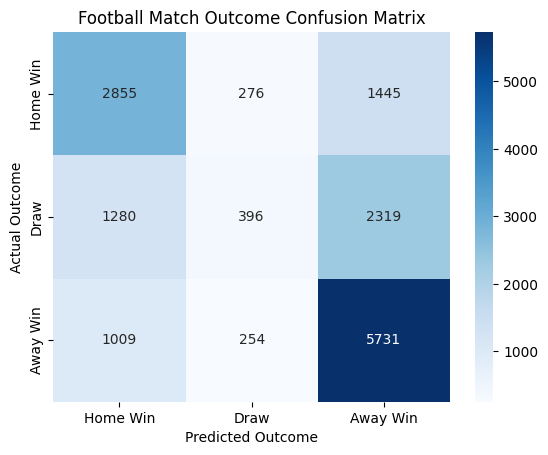

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Create labeled confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['Home Win', 'Draw', 'Away Win']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.title("Football Match Outcome Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.show()